<a href="https://colab.research.google.com/github/m-khujnare2005/Sale-Forecasting-Project/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Walmart.csv to Walmart.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [4]:
df = pd.read_csv('Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [8]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [9]:
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
sales = df[['Date', 'Weekly_Sales']].copy()

sales.columns = ['ds', 'y']

sales.head()

,ds,y
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


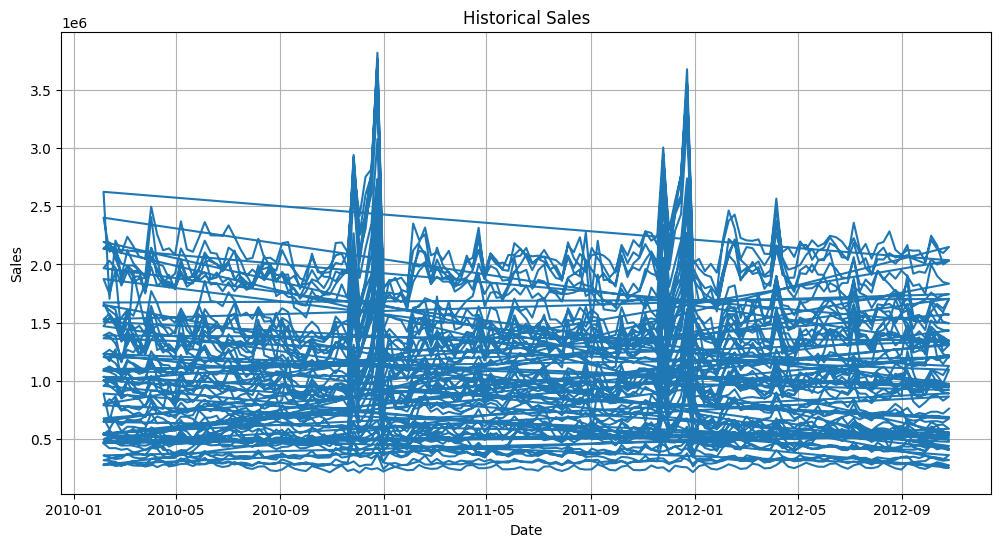

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(sales['ds'], sales['y'])
plt.title('Historical Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [12]:
print(df.columns)

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [13]:
sales_daily = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

sales_daily.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


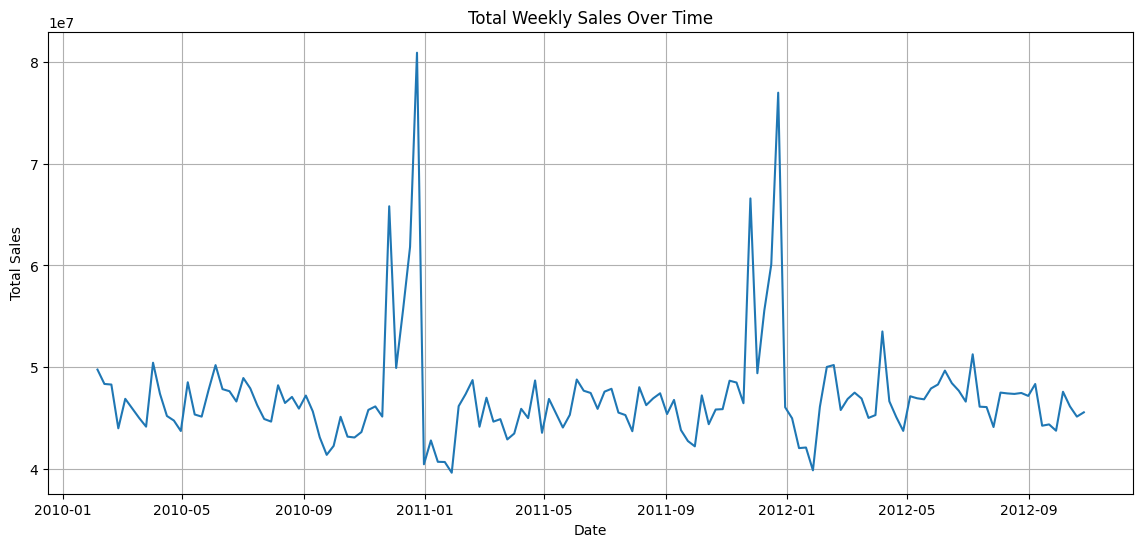

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(sales_daily['Date'], sales_daily['Weekly_Sales'])

plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

In [15]:
sales = sales_daily.copy()

sales.columns = ['ds', 'y']

sales.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [16]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(sales)

In [17]:
future = model.make_future_dataframe(periods=90)

future.tail()

,ds
228,2013-01-20
229,2013-01-21
230,2013-01-22
231,2013-01-23
232,2013-01-24


In [18]:
forecast = model.predict(future)

forecast[['ds','yhat']].tail()

,ds,yhat
228,2013-01-20,3.918219e+07
229,2013-01-21,3.964666e+07
230,2013-01-22,4.019994e+07
231,2013-01-23,4.082748e+07
232,2013-01-24,4.151402e+07


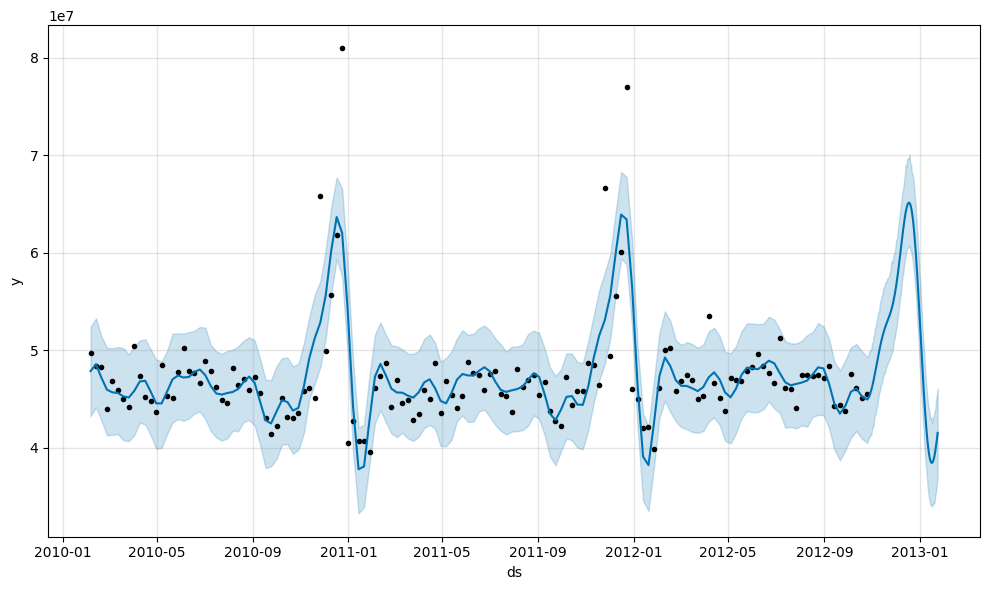

In [19]:
fig = model.plot(forecast)
plt.show()

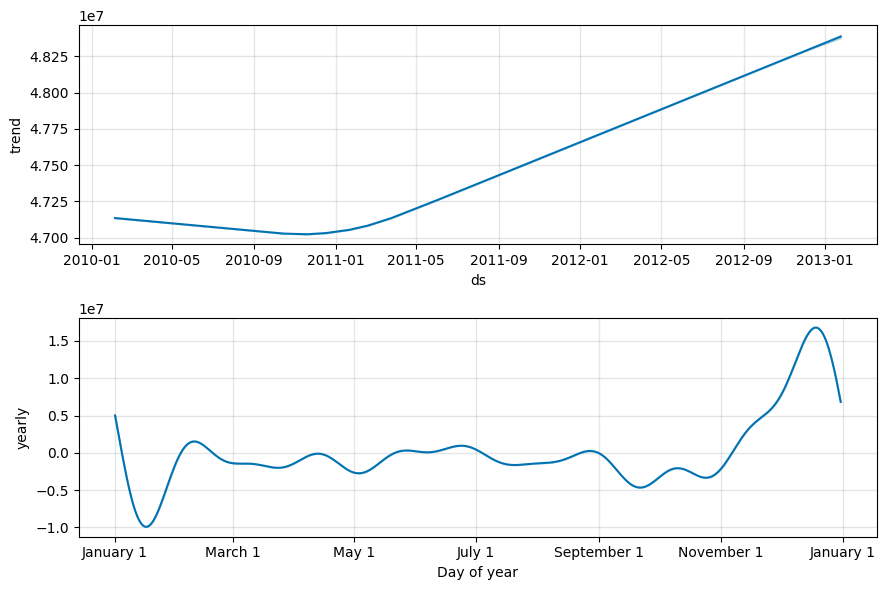

In [20]:
fig2 = model.plot_components(forecast)
plt.show()

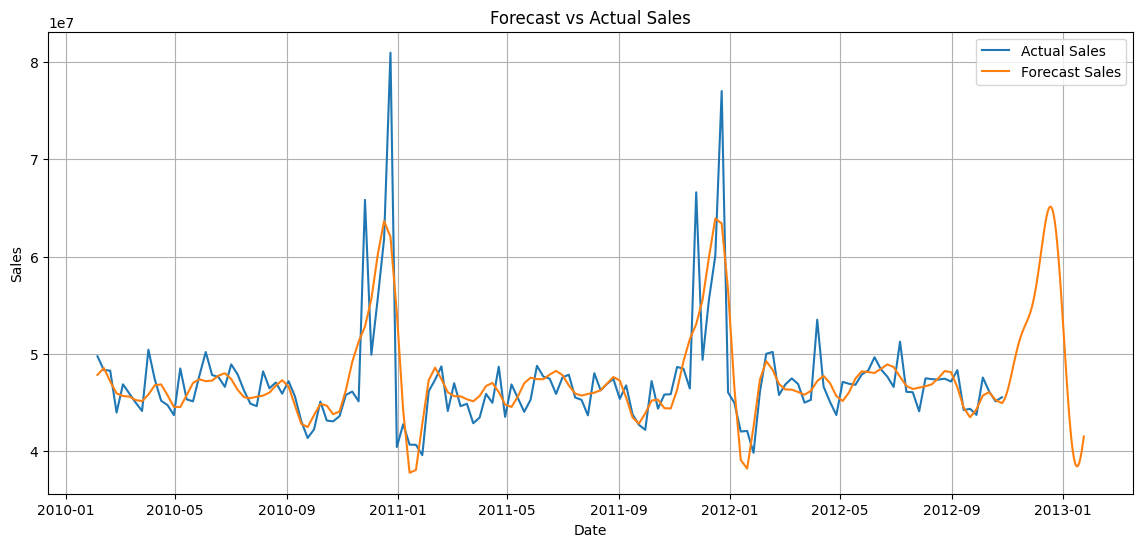

In [21]:
plt.figure(figsize=(14,6))

plt.plot(sales['ds'], sales['y'], label='Actual Sales')

plt.plot(forecast['ds'], forecast['yhat'], label='Forecast Sales')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Forecast vs Actual Sales')

plt.legend()
plt.grid(True)

plt.show()

In [22]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print(holiday_sales)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


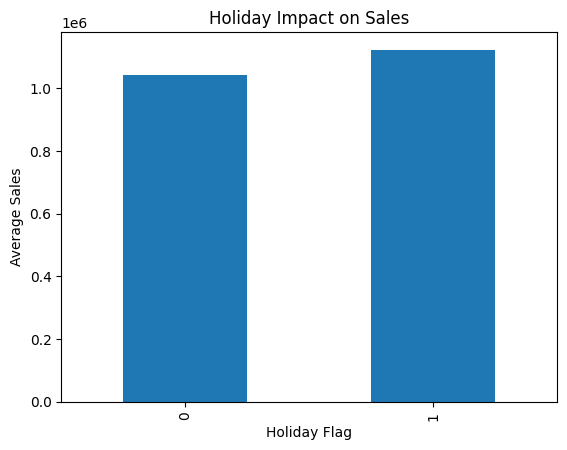

In [23]:
holiday_sales.plot(kind='bar')

plt.title('Holiday Impact on Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Sales')

plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error

In [26]:
pred = forecast['yhat'][:len(sales)]

mae = mean_absolute_error(
    sales['y'],
    pred
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2024315.0670477669


In [27]:
forecast[['ds','yhat']].tail(30)


,ds,yhat
203,2012-12-26,6.112202e+07
204,2012-12-27,6.003951e+07
205,2012-12-28,5.885218e+07
206,2012-12-29,5.757353e+07
207,2012-12-30,5.621889e+07
208,2012-12-31,5.480510e+07
209,2013-01-01,5.335020e+07
210,2013-01-02,5.187311e+07
211,2013-01-03,5.039326e+07
212,2013-01-04,4.893020e+07
